In [1]:
import numpy as np
import gempy as gp
import pandas as pd
import gempy_viewer as gpv
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rasterio

Setting Backend To: AvailableBackends.numpy


In [2]:
#  ====
# Inputs
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (300, -2000)

resolution = [10, 10, 60]   # nx, ny, nz
 
#  ====
extent = x_lims+y_lims+z_lims[::-1]

Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE


c:\Users\ethan\anaconda3\envs\gempy310\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=unknown,
	color=#5DA629,
	is_active=True
),
Element(
	name=B1,
	color=#015482,
	is_active=True
),
Element(
	name=M1,
	color=#728f02,
	is_active=True
),
Element(
	name=B2,
	color=#9f0052,
	is_active=True
),
Element(
	name=M2,
	color=#443988,
	is_active=True
),
Element(
	name=B3,
	color=#ffbe00,
	is_active=True
),
Element(
	name=M3,
	color=#ff3f20,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

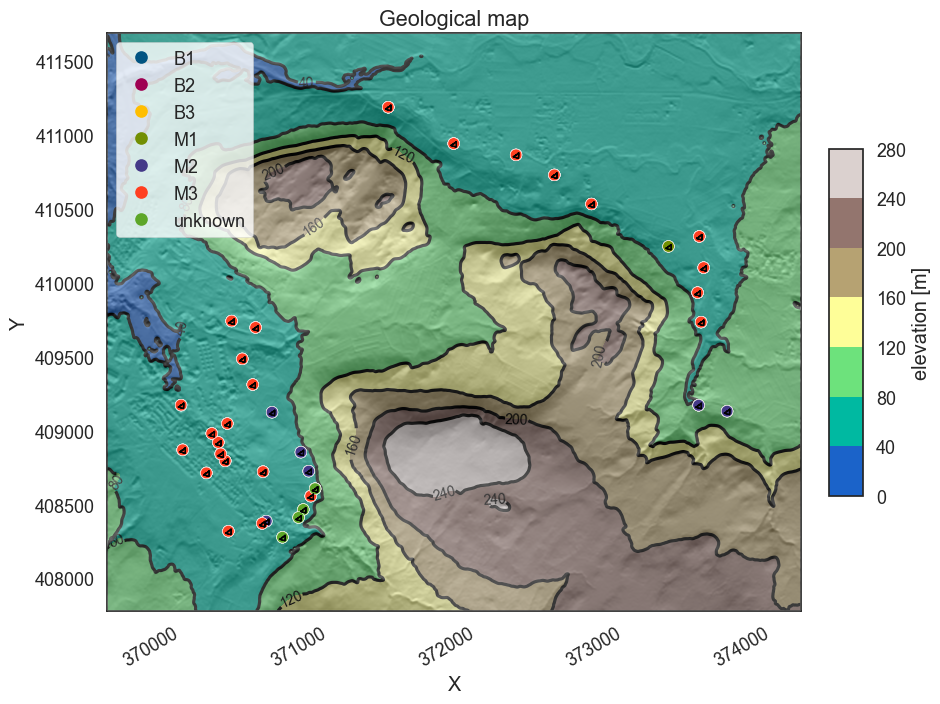

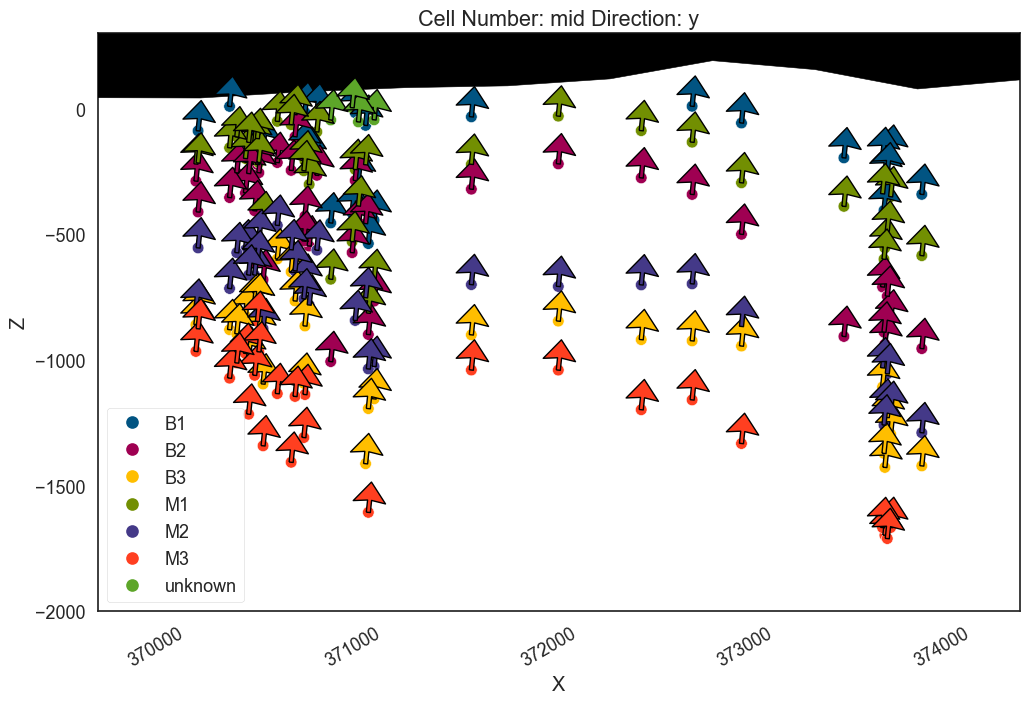

In [8]:
# Create instance of geomodel
geo_model = gp.create_geomodel(
    project_name = 'tutorial_model',
    extent=extent,
    resolution=resolution,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations='df_orientations_4gempy.csv',
        path_to_surface_points='df_surfaces_4gempy.csv'
    )
)

# Add topography
gp.set_topography_from_file(
    grid=geo_model.grid,
    filepath='../DEM/subset_dem.tif')

#Plot map
gpv.plot_2d(geo_model, show_topography=True, section_names=['topography'])

# Display a basic cross section of input data
gpv.plot_2d(geo_model, show_topography=True)

# Define structural groups and age/stratigraphic relationship
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Strat_Series1": ('unknown', 'B1', 'M1', 'B2', 'M2', 'B3', 'M3')
        }
)

In [ ]:
# Compute a solution for the model
gp.compute_model(geo_model)

Setting Backend To: AvailableBackends.numpy


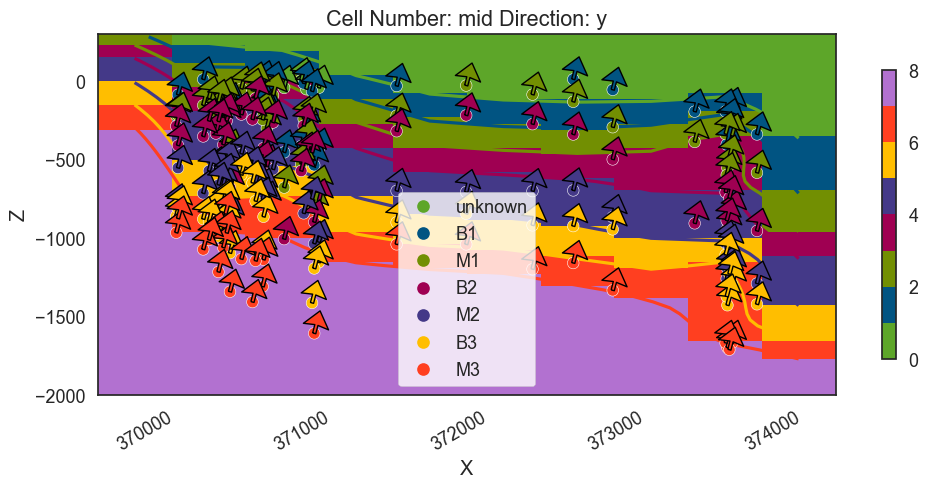

In [ ]:
# Display the result in 2d section
gpv.plot_2d(geo_model)

In [ ]:
plotter = gpv.plot_3d(
    geo_model,
    show_lith=True,
    show_boundaries=True,
    ve=None,
    return_plotter=True
)

plotter.show()
plotter.close()